In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from poincare import PoincareManifold
from poincare_embeddings import Poincarre_embeddings
from sklearn.metrics import pairwise_distances
from sklearn.metrics import average_precision_score
from data import prepare_data
from load_data import * 

/home/onyxia/work/OT_simulation_maladies/Disease_embeddings/load_data.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


In [2]:
# Chargement des données
work = pd.concat([work_omim, work_orpha]).reset_index()
print(f"Taille du jeu de données : {work.shape}")
omim_to_idx = {v: i for i, v in enumerate(work['database_id'].values) if v.startswith('OMIM')} 
orpha_to_idx = {v: i for i, v in enumerate(work['database_id'].values) if v.startswith('ORPHA')}
correspondances = []
for _, row in df_orpha_omim.iterrows():
        if row['omim_id'] in omim_to_idx and row['orpha_id'] in orpha_to_idx:
            i = omim_to_idx[row['omim_id']]
            j = orpha_to_idx[row['orpha_id']]
            correspondances.append((i, j))

Taille du jeu de données : (9751, 11615)


In [3]:
# Chargement du modèle
checkpoint = torch.load('logs/2026_6_12/1/model_final.pt', map_location='cpu', weights_only=False)
data = checkpoint['data']
D_high = checkpoint['distances']
print("Check nb inf :", np.isinf(D_high).sum())
losses = checkpoint['losses']
hp = checkpoint['args']

manifold = PoincareManifold()
model = Poincarre_embeddings(n=len(data), 
    dim=hp['dim'], 
    manifold=manifold, 
    gamma=hp['gamma'],
    learn_curvature=False, 
    init_curvature=1.,
    Qdist='laplace', 
    lossfn='klSym')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Check nb inf : 0


Poincarre_embeddings(
  (embeddings): Embedding(9751, 10, max_norm=0.99)
  (sm): Softmax(dim=1)
  (lsm): LogSoftmax(dim=1)
)

In [4]:
W = model.weight.detach().cpu().numpy()   # (N, dim)
norms = np.linalg.norm(W, axis=1)

print(f"Modèle chargé — {len(data)} nœuds | dim={hp['dim']} | "
      f"{len(losses)} epochs")
print(f"Norme moy={norms.mean():.4f} | max={norms.max():.4f}")

i_min = np.argmin(norms).item()
print(f"Index de la plus petite norme : {i_min}")
print(f"Position du point : {W[i_min]}")

Modèle chargé — 9751 nœuds | dim=10 | 237 epochs
Norme moy=0.0749 | max=0.6353
Index de la plus petite norme : 1424
Position du point : [ 0.00057623  0.00128332  0.00023362  0.00101991  0.0012221   0.00054752
 -0.00095836  0.00113454 -0.00125501 -0.00102196]


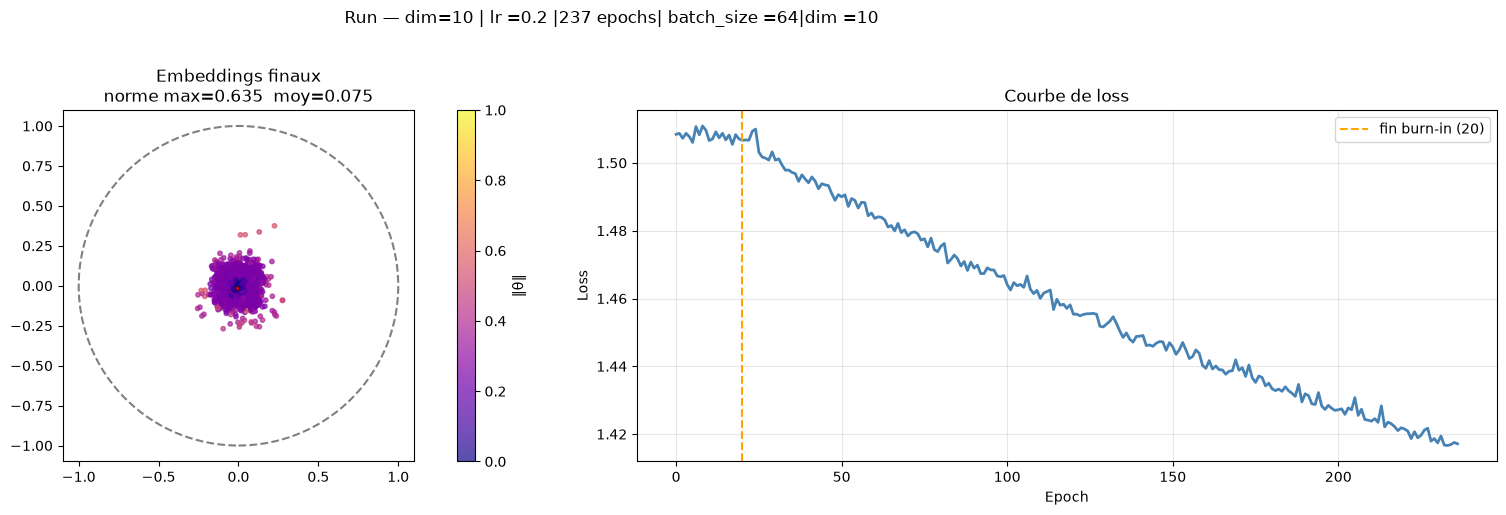

In [5]:
def visualize_training(losses, W, args):

    norms = np.linalg.norm(W, axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # ── 1. Disque de Poincaré ─────────────────────────────────────────
    ax = axes[0]
    ax.add_patch(plt.Circle((0, 0), 1.0, color='gray', fill=False, lw=1.5, ls='--'))
    sc = ax.scatter(W[:, 0], W[:, 1], c=norms, cmap='plasma',
                    s=10, alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='‖θ‖')
    ax.scatter(W[0, 0], W[0, 1], c='red', s=10, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title(f'Embeddings finaux\nnorme max={norms.max():.3f}  moy={norms.mean():.3f}')

    # Loss
    ax = axes[1]
    ax.plot(losses, color='steelblue', lw=2)
    ax.axvline(args["burnin"], color='orange', ls='--', label=f'fin burn-in ({args["burnin"]})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title('Courbe de loss')
    ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle(
        f'Run — dim={W.shape[1]} | lr ={args["lr"]} |'
        f'{len(losses)} epochs| batch_size ={args["batchsize"]}|dim ={args['dim']}',
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    
    #fname = f"plots/omim_{args["epochs"]}_LR{args["lr"]}_G{GAMMA}_D{DIM}.pt.png"
    #plt.savefig(fname, dpi=150, bbox_inches='tight')
    #print(f"Figure sauvegardée : {fname}")
    plt.show()

visualize_training(losses, W, hp)

In [6]:
def get_ranking(distance_matrix):

    # According to this definition, reflexive ranks are set
    # to zero and non-reflexive ranks belong to {1,.., N − 1}.
    n = len(distance_matrix)
    sidx = np.argsort(distance_matrix, axis=1)
    Rank = np.zeros([n, n])
    ranks = np.tile(np.arange(n), (n, 1))
    np.put_along_axis(Rank, sidx[:, 1:], ranks[:, 1:], axis=1)
    return Rank

def get_coRanking(Rank_high, Rank_low):
    """
    Retourne une matrice binaire où une entrée vaut 1 si les deux noeuds sont "voisins" dans les deux matrices.
    """
    N = len(Rank_high)
    k = Rank_high.astype(int).ravel()
    l = Rank_low.astype(int).ravel()
    mask = (k > 0) & (l > 0)
    coRank = np.zeros([N-1, N-1])
    coRank = np.bincount(
        (k[mask] - 1) * (N - 1) + (l[mask] - 1),
        minlength=(N - 1) ** 2
    ).reshape(N - 1, N - 1)

    return coRank


In [7]:
def get_score(Rank_high, Rank_low):

    coRank = get_coRanking(Rank_high, Rank_low)
    N = len(coRank)+1

    df_score = pd.DataFrame(columns=['Qnx', 'Bnx'])
    Qnx = 0
    Bnx = 0
    for K in range(1, N):
        Qnx += sum(coRank[:K, K-1]) + sum(coRank[K-1, :K]) - coRank[K-1, K-1]
        Bnx += sum(coRank[:K, K-1]) - sum(coRank[K-1, :K])
        df_score.loc[len(df_score)] = [Qnx /(K*N), Bnx/(K*N)]
    
    return df_score

'''
    # Sommes cumulatives sur les lignes et colonnes
    row_cumsum = np.cumsum(coRank, axis=0)  # somme cumulée sur les lignes
    col_cumsum = np.cumsum(coRank, axis=1)  # somme cumulée sur les colonnes
    diag = np.diag(coRank)

    # Pour chaque K : sum(coRank[:K, K-1]) + sum(coRank[K-1, :K]) - coRank[K-1,K-1]
    # = col_cumsum[K-1, K-1] + row_cumsum[K-1, K-1] - diag[K-1]
    Ks = np.arange(1, N)
    qnx_increments = col_cumsum[Ks-1, Ks-1] + row_cumsum[Ks-1, Ks-1] - diag
    bnx_increments = col_cumsum[Ks-1, Ks-1] - row_cumsum[Ks-1, Ks-1]

    Qnx = np.cumsum(qnx_increments) / (Ks * N)
    Bnx = np.cumsum(bnx_increments) / (Ks * N)

    df_score = pd.DataFrame({'Qnx': Qnx, 'Bnx': Bnx})
    return df_score
''' 


"\n    # Sommes cumulatives sur les lignes et colonnes\n    row_cumsum = np.cumsum(coRank, axis=0)  # somme cumulée sur les lignes\n    col_cumsum = np.cumsum(coRank, axis=1)  # somme cumulée sur les colonnes\n    diag = np.diag(coRank)\n\n    # Pour chaque K : sum(coRank[:K, K-1]) + sum(coRank[K-1, :K]) - coRank[K-1,K-1]\n    # = col_cumsum[K-1, K-1] + row_cumsum[K-1, K-1] - diag[K-1]\n    Ks = np.arange(1, N)\n    qnx_increments = col_cumsum[Ks-1, Ks-1] + row_cumsum[Ks-1, Ks-1] - diag\n    bnx_increments = col_cumsum[Ks-1, Ks-1] - row_cumsum[Ks-1, Ks-1]\n\n    Qnx = np.cumsum(qnx_increments) / (Ks * N)\n    Bnx = np.cumsum(bnx_increments) / (Ks * N)\n\n    df_score = pd.DataFrame({'Qnx': Qnx, 'Bnx': Bnx})\n    return df_score\n"

In [8]:
def get_scalars(Qnx):
    
    N = len(Qnx) # total length of Qnx is smaller than number of samples
    K_max = 0
    val_max = Qnx[0] - 1/N
    for k in range(1, N):
        if val_max < (Qnx[k] - (k+1)/N):
            val_max = Qnx[k] - (k+1)/N
            K_max = k

    Qlocal = np.mean(Qnx[:K_max+1])
    Qglobal = np.mean(Qnx[K_max:])

    return Qlocal, Qglobal, K_max

In [9]:
def poincare_distance(x, eps=1e-5):
    boundary = 1 - eps
    nx = x.size(0)
    x = x.contiguous().view(nx, -1)

    norm_x = torch.sum(x ** 2, 1, keepdim=True)
    
    dot = x @ x.t()
    sqdist = norm_x + norm_x.t() - 2 * dot
    sqdist = sqdist.clamp(min=0) * 2 
    
    squnorm = 1 - torch.clamp(norm_x, 0, boundary)
    x = (sqdist / torch.mm(squnorm, squnorm.t())) + 1
    z = torch.sqrt(torch.pow(x, 2) - 1)
    
    return torch.log(x + z)

In [10]:
def average_precision_score_batched(D_high, D_low, k=10, batch_size=128):
    n = D_high.shape[0]
    ap_scores = []
    
    knn_high = np.argsort(D_high, axis=1)[:, 1:k+1]  # exclut la diagonale
    y_true = np.zeros((n, n), dtype=np.float32)
    np.put_along_axis(y_true, knn_high, 1.0, axis=1)

    for i in range(0, n, batch_size):
        y_batch = y_true[i:i+batch_size]
        s_batch = -D_low[i:i+batch_size]
        
        sorted_idx = np.argsort(-s_batch, axis=1)
        sorted_true = np.take_along_axis(y_batch, sorted_idx, axis=1)
        
        cumsum = np.cumsum(sorted_true, axis=1)
        k = np.arange(1, n + 1)
        precision_at_k = cumsum / k
        
        n_relevant = sorted_true.sum(axis=1)
        ap = (precision_at_k * sorted_true).sum(axis=1) / np.maximum(n_relevant, 1)
        ap_scores.extend(ap.tolist())
    
    return np.mean(ap_scores)

In [11]:
def get_quality_metrics(coord_high, coord_low, D_high, distance='euclidean', 
#k_neighbours=20, 
verbose=False):
    """
    Implementation of 'Scale-independent quality criteria' from Lee et al.    
    Parameters
    ----------
    coord_high : np.array
        Feature matrix of the sample in the high dimensional space.
    coord_low : np.array
        Low dimensional embedding of the sample.
    distance : str (default: 'euclidean')
        Distance metric to compute distanced between points in low dimendional 
        space. Possible parameters: 'euclidean' or 'poincare'.
    verbose: bool (default: False)
        A flag if to print the results of the computations.    
    k_neighbours: int (default: 20)
        k-nearest neighbours for setting
    Returns
    -------
    Qlocal: float
        Quality criteria for local qualities of the embedding.
        Range from 0 (bad) to 1 (good).
    Qglobal: float
        Quality criteria for global qualities of the embedding.
        Range from 0 (bad) to 1 (good).
    Kmax: int
        Kmax defines the split of the QNX curv.
    """

    Rank_high = get_ranking(D_high)

    if distance == 'euclidean':     
        D_low = pairwise_distances(coord_low)
    elif distance == 'poincare':
        D_low = poincare_distance(torch.DoubleTensor(coord_low)).numpy()
    else:
        raise NotImplementedError
    print(D_low.shape)
    print("Nb inf :", np.isinf(D_low).sum())
    print("==== Get ranking ====")
    Rank_low = get_ranking(D_low)
    print("==== Get score ====")
    df_score = get_score(Rank_high, Rank_low)
    print("==== Average precision ====")
    ap_scores = average_precision_score_batched(D_high, D_low)
    print ("==== Get scalars ====")
    Qlocal, Qglobal, Kmax = get_scalars(df_score['Qnx'].values)
    if verbose:
        print(f"Qlocal = {Qlocal:.2f}, Qglobal = {Qglobal:.2f}, Kmax = {Kmax}, ap_scores = {ap_scores}")

    return Qlocal, Qglobal, Kmax, ap_scores

In [12]:
Qlocal, Qglobal, Kmax, ap_scores = get_quality_metrics(data, W, D_high, distance='poincare', verbose=True)

(9751, 9751)
Nb inf : 0
==== Get ranking ====
==== Get score ====
==== Average precision ====
==== Get scalars ====
Qlocal = 0.22, Qglobal = 0.68, Kmax = 1876, ap_scores = 0.026833131737520135


In [23]:
n, d = work_orpha.shape
m, d = work_omim.shape

Qlocal, Qglobal, Kmax, ap_scores = get_quality_metrics(data, W[:m], D_high[:m, :m], distance='poincare', verbose=True)
Qlocal, Qglobal, Kmax, ap_scores = get_quality_metrics(data, W[m:], D_high[m:, m:], distance='poincare', verbose=True)

(6562, 6562)
Nb inf : 0
==== Get ranking ====
==== Get score ====
==== Average precision ====
==== Get scalars ====
Qlocal = 0.23, Qglobal = 0.69, Kmax = 1142, ap_scores = 0.037688522397685775
(3189, 3189)
Nb inf : 0
==== Get ranking ====
==== Get score ====
==== Average precision ====
==== Get scalars ====
Qlocal = 0.22, Qglobal = 0.70, Kmax = 785, ap_scores = 0.016079435398649863
